<a href="https://colab.research.google.com/github/rai8896/Deep_Learning_Lab/blob/main/Exeperiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A (Autoencoder)
- ├── Step 1  — Imports & Device
- ├── Step  2  — Dataset Load & Split
- ├── Step  3  — Autoencoder Architecture
- ├── Step  4  — Loss Functions & Optimizers
- ├── Step  5  — Training Loop
- ├── Step  6  — Loss Curves
- ├── Step  7  — Reconstruction Visualization
- ├── Step  8  — Latent Interpolation
- ├── Step  9  — Latent Dim Experiment (2/8/16/32)
- ├── Step  10 — Optimizer & Loss Fn Comparison
- ├── Step  11 — 2D Latent Space Scatter Plot
- └── Step  12 — AE vs VAE Preview

> Add blockquote



Step 1 — Imports & Device

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Step 2 — Dataset Load & Split

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),          # [0,1] range
])

# Full dataset download
full_train = datasets.FashionMNIST(root='./data', train=True,
                                    download=True, transform=transform)
test_ds    = datasets.FashionMNIST(root='./data', train=False,
                                    download=True, transform=transform)

# 80% train, 10% val from train set
train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

# DataLoaders
BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 157kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]

Train: 48000 | Val: 12000 | Test: 10000


Step 3 — Autoencoder Architecture

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        # Decoder (mirror of encoder)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),   # output in [0,1] for BCE
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)        # flatten: (B, 784)
        z = self.encoder(x)               # latent
        x_hat = self.decoder(z)           # reconstruction
        return x_hat, z

# Test karo
model = Autoencoder(latent_dim=16).to(device)
print(model)


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


Step 4 — Loss Functions & Optimizers

In [ ]:
# Loss functions
bce_loss = nn.BCELoss()          # Binary Cross-Entropy (recommended)
mse_loss = nn.MSELoss()          # Mean Squared Error

def get_loss(loss_type, x_hat, x_flat):
    if loss_type == "bce":
        return bce_loss(x_hat, x_flat)
    else:
        return mse_loss(x_hat, x_flat)

# Optimizers - baad mein compare karna hai
def get_optimizer(name, model, lr=1e-3):
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    elif name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)

optimizer = get_optimizer("adam", model)

 Step 5 — Training Loop

In [ ]:
def train_autoencoder(model, optimizer, epochs=20,
                       loss_type="bce", device=device):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_train = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            x_flat = imgs.view(imgs.size(0), -1)

            optimizer.zero_grad()
            x_hat, z = model(imgs)
            loss = get_loss(loss_type, x_hat, x_flat)
            loss.backward()
            optimizer.step()
            total_train += loss.item()

        # --- Validation ---
        model.eval()
        total_val = 0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)
                x_flat = imgs.view(imgs.size(0), -1)
                x_hat, _ = model(imgs)
                total_val += get_loss(loss_type, x_hat, x_flat).item()

        avg_train = total_train / len(train_loader)
        avg_val   = total_val   / len(val_loader)
        train_losses.append(avg_train)
        val_losses.append(avg_val)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    return train_losses, val_losses

# Run training
train_l, val_l = train_autoencoder(model, optimizer, epochs=20, loss_type="bce")

Epoch 5/20 | Train Loss: 0.2823 | Val Loss: 0.2806
Epoch 10/20 | Train Loss: 0.2746 | Val Loss: 0.2744
Epoch 15/20 | Train Loss: 0.2720 | Val Loss: 0.2728
Epoch 20/20 | Train Loss: 0.2706 | Val Loss: 0.2713


Step 6 — Loss Curves

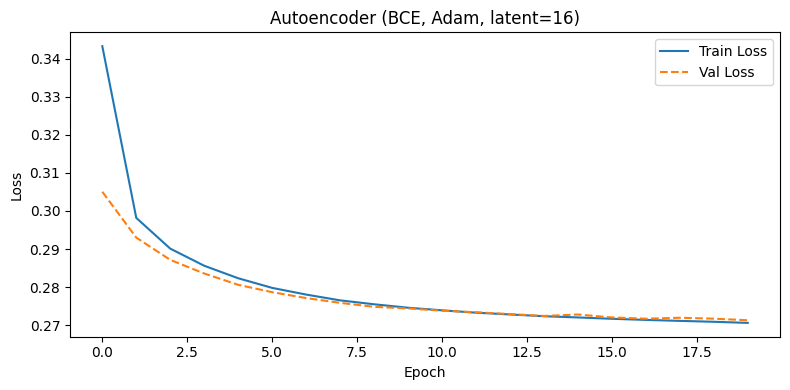

In [ ]:
def plot_losses(train_losses, val_losses, title="Autoencoder Loss"):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_losses(train_l, val_l, "Autoencoder (BCE, Adam, latent=16)")

Step 7 — Reconstruction Visualization

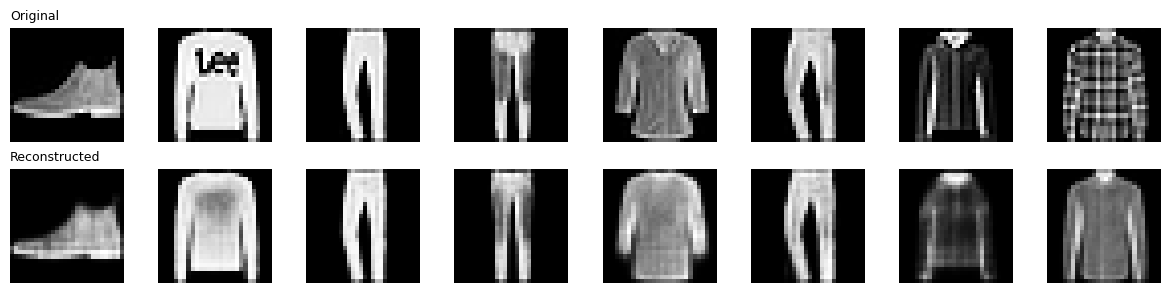

In [ ]:
def show_reconstructions(model, loader, n=8, device=device):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(device)

    with torch.no_grad():
        recon, _ = model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3))
    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        # Reconstruction
        axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_title("Original", loc='left', fontsize=9)
    axes[1, 0].set_title("Reconstructed", loc='left', fontsize=9)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader)

 Step 8 — Latent Interpolation

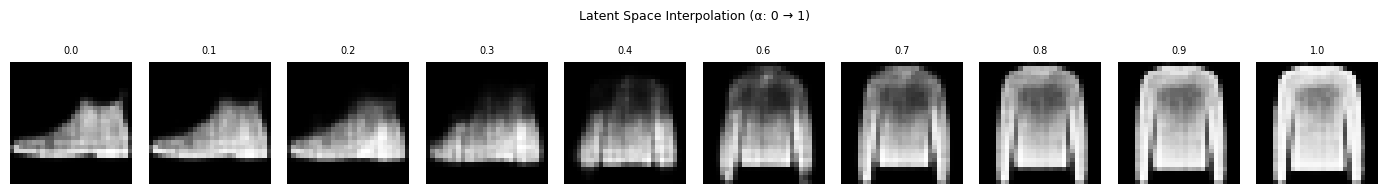

In [ ]:
def interpolate_latent(model, loader, steps=10, device=device):
    model.eval()
    imgs, _ = next(iter(loader))
    img1 = imgs[0:1].to(device)
    img2 = imgs[1:2].to(device)

    with torch.no_grad():
        _, z1 = model(img1)
        _, z2 = model(img2)

    alphas = torch.linspace(0, 1, steps)
    interp_imgs = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2
        out = model.decoder(z_interp)
        interp_imgs.append(out.detach().cpu().view(28, 28)) # Added .detach()

    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.4, 1.8))
    for i, im in enumerate(interp_imgs):
        axes[i].imshow(im, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"{alphas[i]:.1f}", fontsize=7)
    plt.suptitle("Latent Space Interpolation (α: 0 → 1)", fontsize=9, y=1.05)
    plt.tight_layout()
    plt.show()

interpolate_latent(model, test_loader)


Step 9 — Latent Dim Experiment (2/8/16/32)


  Training Autoencoder | Latent Dim = 2
Epoch 5/15 | Train Loss: 0.3226 | Val Loss: 0.3213
Epoch 10/15 | Train Loss: 0.3188 | Val Loss: 0.3186
Epoch 15/15 | Train Loss: 0.3164 | Val Loss: 0.3171
  Best Val Loss: 0.3167

  Training Autoencoder | Latent Dim = 8
Epoch 5/15 | Train Loss: 0.2864 | Val Loss: 0.2856
Epoch 10/15 | Train Loss: 0.2813 | Val Loss: 0.2817
Epoch 15/15 | Train Loss: 0.2792 | Val Loss: 0.2795
  Best Val Loss: 0.2795

  Training Autoencoder | Latent Dim = 16
Epoch 5/15 | Train Loss: 0.2821 | Val Loss: 0.2807
Epoch 10/15 | Train Loss: 0.2747 | Val Loss: 0.2747
Epoch 15/15 | Train Loss: 0.2721 | Val Loss: 0.2726
  Best Val Loss: 0.2726

  Training Autoencoder | Latent Dim = 32
Epoch 5/15 | Train Loss: 0.2833 | Val Loss: 0.2818
Epoch 10/15 | Train Loss: 0.2745 | Val Loss: 0.2738
Epoch 15/15 | Train Loss: 0.2702 | Val Loss: 0.2703
  Best Val Loss: 0.2703

Latent Dim      Best Val Loss  
------------------------------
2               0.3167         
8               0.2795

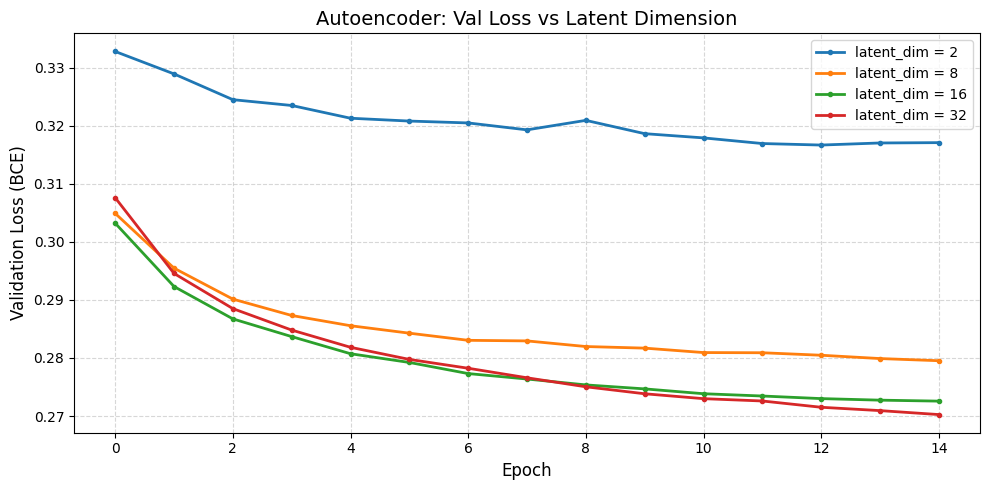

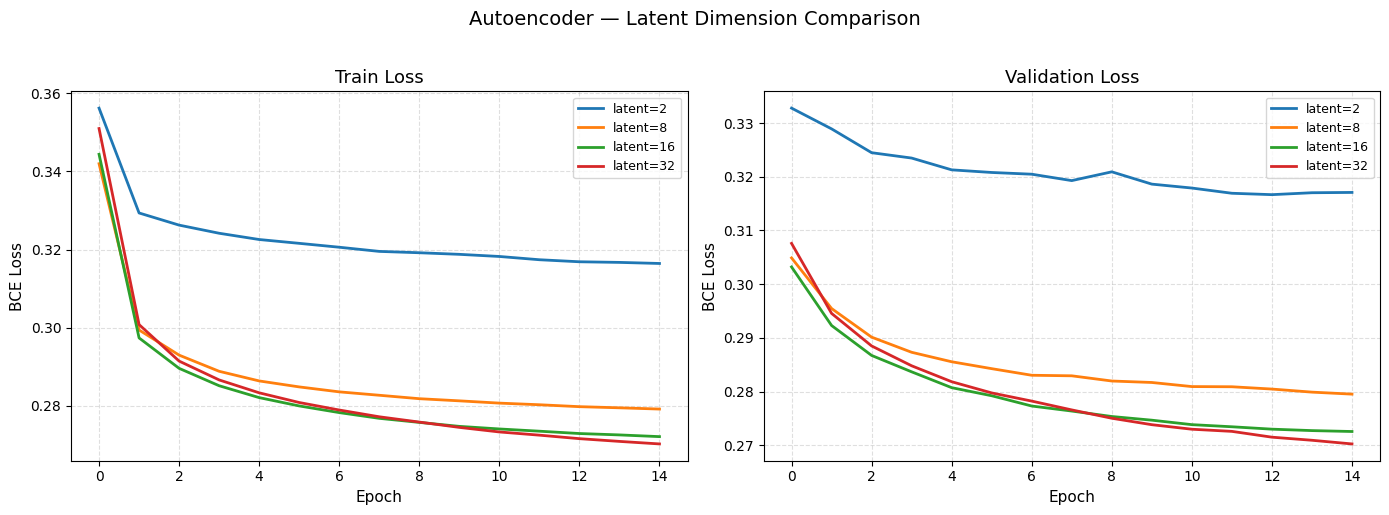

In [ ]:
# ============================================================
# Cell 9 — Experiment: Different Latent Dimensions
# Compare latent_dim = 2, 8, 16, 32 on Autoencoder
# ============================================================

latent_dims = [2, 8, 16, 32]
results = {}

for ld in latent_dims:
    print(f"\n{'='*40}")
    print(f"  Training Autoencoder | Latent Dim = {ld}")
    print(f"{'='*40}")

    # Fresh model aur optimizer har latent dim ke liye
    m   = Autoencoder(latent_dim=ld).to(device)
    opt = get_optimizer("adam", m, lr=1e-3)

    # Train karo aur losses save karo
    train_losses, val_losses = train_autoencoder(
        model     = m,
        optimizer = opt,
        epochs    = 15,
        loss_type = "bce",
        device    = device
    )

    # Results dictionary mein store karo
    results[ld] = {
        "model"  : m,
        "train"  : train_losses,
        "val"    : val_losses,
        "best_val": min(val_losses)       # best val loss track karo
    }

    print(f"  Best Val Loss: {results[ld]['best_val']:.4f}")

# -------------------------------------------------------
# Summary Table print karo
# -------------------------------------------------------
print(f"\n{'Latent Dim':<15} {'Best Val Loss':<15}")
print("-" * 30)
for ld in latent_dims:
    print(f"{ld:<15} {results[ld]['best_val']:<15.4f}")

# -------------------------------------------------------
# Plot: Val Loss vs Epoch for all latent dims
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

for ld in latent_dims:
    plt.plot(
        results[ld]["val"],
        label     = f"latent_dim = {ld}",
        linewidth = 2,
        marker    = 'o',
        markersize= 3
    )

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Loss (BCE)", fontsize=12)
plt.title("Autoencoder: Val Loss vs Latent Dimension", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("latent_dim_comparison.png", dpi=150)   # W&B ke liye save karo
plt.show()

# -------------------------------------------------------
# Plot: Train Loss bhi compare karo (side-by-side)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ld in latent_dims:
    axes[0].plot(results[ld]["train"], label=f"latent={ld}", linewidth=2)
    axes[1].plot(results[ld]["val"],   label=f"latent={ld}", linewidth=2)

for ax, title in zip(axes, ["Train Loss", "Validation Loss"]):
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("BCE Loss", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Autoencoder — Latent Dimension Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("latent_dim_train_val_comparison.png", dpi=150)
plt.show()

 Step 10 — Optimizer & Loss Fn Comparison


  Config: Optimizer=ADAM | Loss=BCE
Epoch 5/15 | Train Loss: 0.2829 | Val Loss: 0.2817
Epoch 10/15 | Train Loss: 0.2754 | Val Loss: 0.2752
Epoch 15/15 | Train Loss: 0.2724 | Val Loss: 0.2727
  Best Val Loss : 0.2727
  Final Val Loss: 0.2727

  Config: Optimizer=ADAM | Loss=MSE
Epoch 5/15 | Train Loss: 0.0137 | Val Loss: 0.0135
Epoch 10/15 | Train Loss: 0.0113 | Val Loss: 0.0115
Epoch 15/15 | Train Loss: 0.0103 | Val Loss: 0.0107
  Best Val Loss : 0.0106
  Final Val Loss: 0.0107

  Config: Optimizer=SGD | Loss=BCE
Epoch 5/15 | Train Loss: 0.6865 | Val Loss: 0.6858
Epoch 10/15 | Train Loss: 0.6761 | Val Loss: 0.6745
Epoch 15/15 | Train Loss: 0.6168 | Val Loss: 0.5905
  Best Val Loss : 0.5905
  Final Val Loss: 0.5905

  Config: Optimizer=RMSPROP | Loss=BCE
Epoch 5/15 | Train Loss: 0.2979 | Val Loss: 0.2961
Epoch 10/15 | Train Loss: 0.2856 | Val Loss: 0.2822
Epoch 15/15 | Train Loss: 0.2809 | Val Loss: 0.2806
  Best Val Loss : 0.2806
  Final Val Loss: 0.2806

Config                    Bes

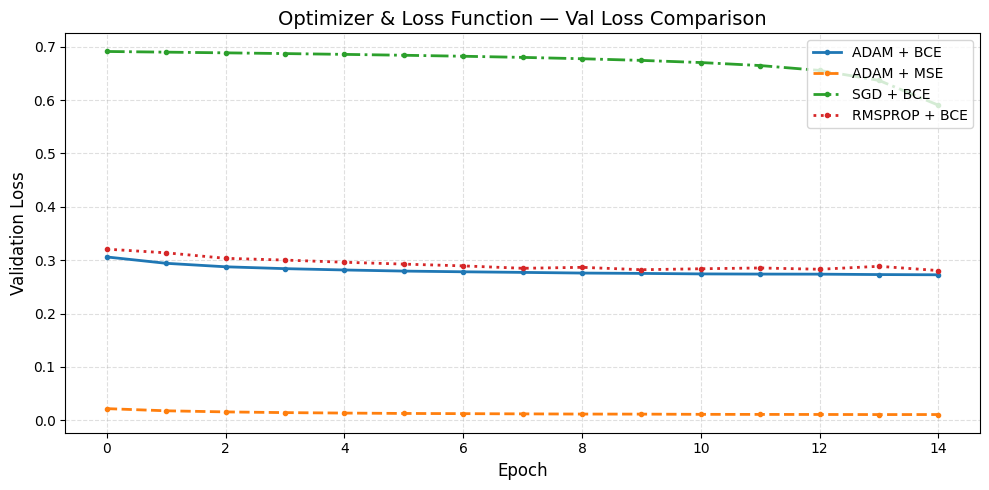

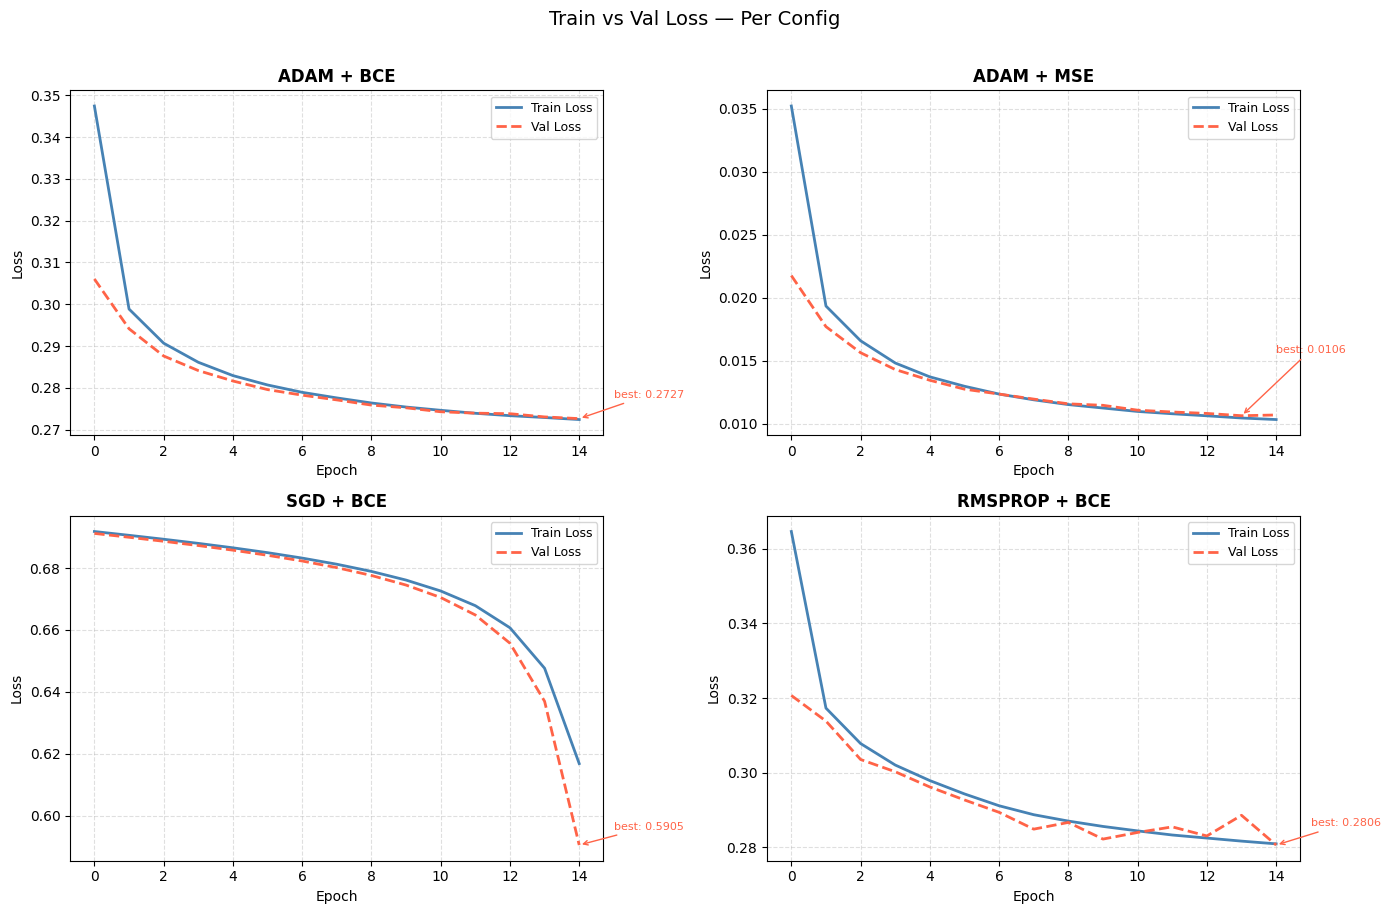

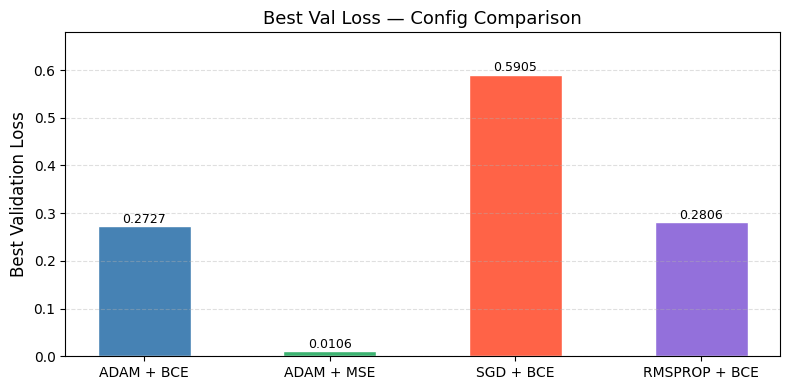

In [ ]:
# ============================================================
# Cell 10 — Experiment: Optimizer & Loss Function Comparison
# Fixed: latent_dim=16 | Vary: optimizer + loss function
# ============================================================

configs = [
    ("adam",    "bce"),   # Baseline — recommended combo
    ("adam",    "mse"),   # Loss fn ka effect dekhna
    ("sgd",     "bce"),   # Slower convergence expected
    ("rmsprop", "bce"),   # Adaptive lr, adam se compare
]

compare = {}

for opt_name, loss_type in configs:
    key = f"{opt_name.upper()} + {loss_type.upper()}"
    print(f"\n{'='*45}")
    print(f"  Config: Optimizer={opt_name.upper()} | Loss={loss_type.upper()}")
    print(f"{'='*45}")

    # Har config ke liye fresh model — fair comparison ke liye
    m   = Autoencoder(latent_dim=16).to(device)
    opt = get_optimizer(opt_name, m, lr=1e-3)

    train_losses, val_losses = train_autoencoder(
        model     = m,
        optimizer = opt,
        epochs    = 15,
        loss_type = loss_type,
        device    = device
    )

    compare[key] = {
        "model"    : m,
        "train"    : train_losses,
        "val"      : val_losses,
        "best_val" : min(val_losses),
        "opt"      : opt_name,
        "loss_fn"  : loss_type,
    }

    print(f"  Best Val Loss : {compare[key]['best_val']:.4f}")
    print(f"  Final Val Loss: {val_losses[-1]:.4f}")

# -------------------------------------------------------
# Summary Table
# -------------------------------------------------------
print(f"\n{'Config':<25} {'Best Val Loss':<18} {'Final Val Loss'}")
print("-" * 58)
for key, res in compare.items():
    print(f"{key:<25} {res['best_val']:<18.4f} {res['val'][-1]:.4f}")

# -------------------------------------------------------
# Plot 1 — Val Loss Comparison (all configs)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

styles = ['-', '--', '-.', ':']   # alag line style har config ke liye

for i, (key, res) in enumerate(compare.items()):
    plt.plot(
        res["val"],
        label     = key,
        linewidth = 2,
        linestyle = styles[i % len(styles)],
        marker    = 'o',
        markersize= 3
    )

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.title("Optimizer & Loss Function — Val Loss Comparison", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("optimizer_loss_val_comparison.png", dpi=150)
plt.show()

# -------------------------------------------------------
# Plot 2 — Train vs Val (2x2 subplots, ek config per plot)
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (key, res) in enumerate(compare.items()):
    ax = axes[i]
    ax.plot(res["train"], label="Train Loss", linewidth=2, color='steelblue')
    ax.plot(res["val"],   label="Val Loss",   linewidth=2, color='tomato', linestyle='--')

    ax.set_title(key, fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Best val loss annotate karo
    best_epoch = res["val"].index(res["best_val"])
    ax.annotate(
        f"best: {res['best_val']:.4f}",
        xy        = (best_epoch, res["best_val"]),
        xytext    = (best_epoch + 1, res["best_val"] + 0.005),
        fontsize  = 8,
        color     = 'tomato',
        arrowprops= dict(arrowstyle='->', color='tomato', lw=1)
    )

plt.suptitle("Train vs Val Loss — Per Config", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("optimizer_loss_train_val_subplots.png", dpi=150)
plt.show()

# -------------------------------------------------------
# Plot 3 — Bar chart: Best Val Loss per config
# -------------------------------------------------------
keys       = list(compare.keys())
best_vals  = [compare[k]["best_val"] for k in keys]
colors     = ['steelblue', 'mediumseagreen', 'tomato', 'mediumpurple']

plt.figure(figsize=(8, 4))
bars = plt.bar(keys, best_vals, color=colors, edgecolor='white', width=0.5)

# Value label har bar ke upar
for bar, val in zip(bars, best_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}",
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Best Validation Loss", fontsize=12)
plt.title("Best Val Loss — Config Comparison", fontsize=13)
plt.ylim(0, max(best_vals) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("optimizer_loss_bar_chart.png", dpi=150)
plt.show()

Step 11 — 2D Latent Space Scatter Plot

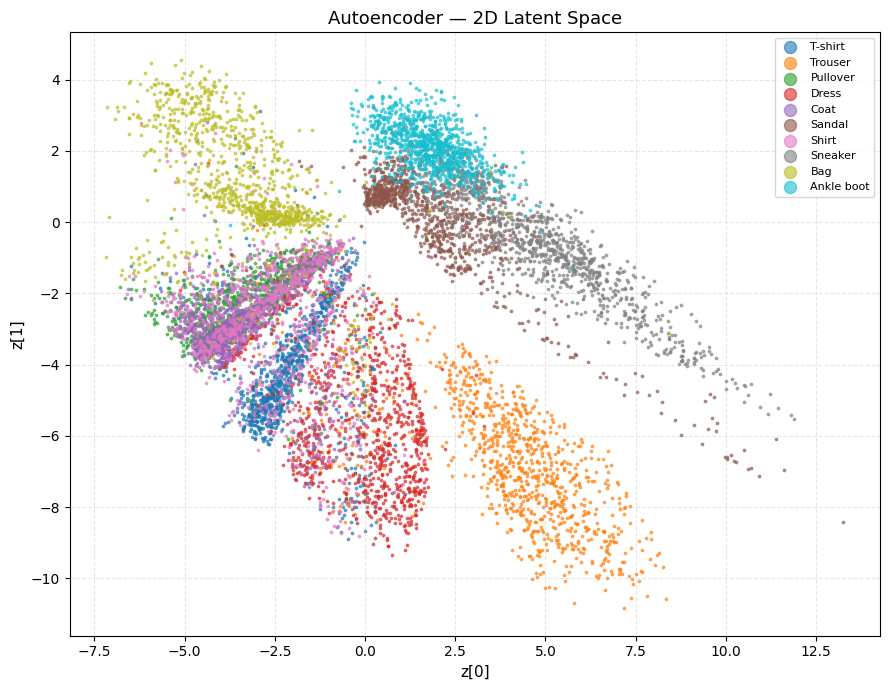

In [ ]:
# ============================================================
# Cell 11 — 2D Latent Space Visualization
# Sirf latent_dim=2 wale model ke liye scatter plot
# ============================================================

def plot_latent_2d(model, loader, device=device):
    model.eval()
    zs, labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            _, z = model(imgs)
            zs.append(z.cpu().numpy())
            labels.append(lbls.numpy())

    zs     = np.concatenate(zs)
    labels = np.concatenate(labels)

    class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',   'Coat',
                   'Sandal',  'Shirt',   'Sneaker',  'Bag',     'Ankle boot']

    plt.figure(figsize=(9, 7))
    for i in range(10):
        mask = labels == i
        plt.scatter(zs[mask, 0], zs[mask, 1],
                    s=3, label=class_names[i], alpha=0.6)

    plt.legend(markerscale=5, fontsize=8, loc='best')
    plt.title("Autoencoder — 2D Latent Space", fontsize=13)
    plt.xlabel("z[0]", fontsize=11)
    plt.ylabel("z[1]", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig("ae_latent_2d.png", dpi=150)
    plt.show()


# results[2] = latent_dim=2 wala model (Cell 9 se)
plot_latent_2d(results[2]["model"], test_loader)

Step 12 — AE vs VAE Preview

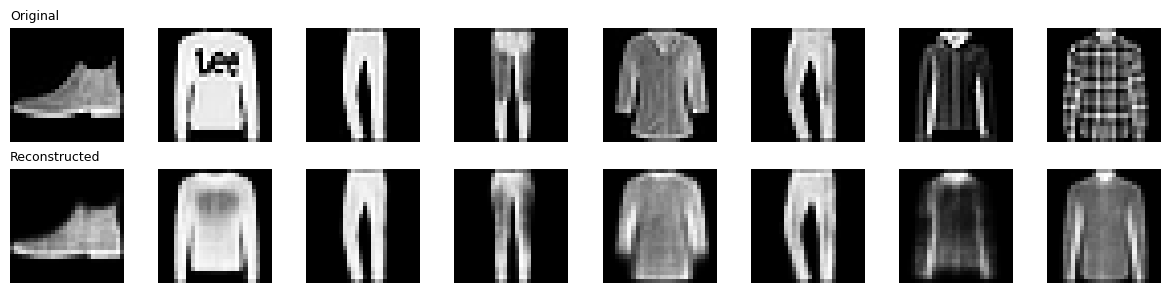

In [ ]:
# ============================================================
# Cell 12 — Autoencoder vs VAE Comparison (Preview)
# Reconstruction quality side-by-side compare karo
# ============================================================

def compare_ae_vae(ae_model, vae_model, loader, n=8, device=device):
    ae_model.eval()
    vae_model.eval()

    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(device)

    with torch.no_grad():
        ae_recon, _          = ae_model(imgs)
        vae_recon, _, _, _   = vae_model(imgs)

    fig, axes = plt.subplots(3, n, figsize=(n * 1.5, 4.5))

    row_titles = ["Original", "AE Recon", "VAE Recon"]

    for i in range(n):
        axes[0, i].imshow(imgs[i].cpu().squeeze(),        cmap='gray')
        axes[1, i].imshow(ae_recon[i].cpu().view(28,28),  cmap='gray')
        axes[2, i].imshow(vae_recon[i].cpu().view(28,28), cmap='gray')

        for row in range(3):
            axes[row, i].axis('off')

    for row, title in enumerate(row_titles):
        axes[row, 0].set_title(title, loc='left', fontsize=9, fontweight='bold')

    plt.suptitle("Autoencoder vs VAE — Reconstruction Comparison", fontsize=12)
    plt.tight_layout()
    plt.savefig("ae_vs_vae_reconstruction.png", dpi=150)
    plt.show()


# AE: latent_dim=16, Adam, BCE wala model use karo
# VAE: Part B Cell 5 ka trained model
ae_best  = compare["ADAM + BCE"]["model"]   # Cell 10 se
# vae_best = vae                            # Part B complete hone ke baad run karna

# Abhi sirf AE reconstruction dikhao
show_reconstructions(ae_best, test_loader)

# Part B complete hone ke baad yeh uncomment karo:
# compare_ae_vae(ae_best, vae_best, test_loader)


 # Part B (VAE)
- ├── step 1  — Imports & Device
- ├── step 2  — Dataset Load & Split
- ├── step 3  — VAE Architecture
- ├── step 4  — VAE Loss (Recon + KL)
- ├── step 5  — Training Loop
- ├── step 6  — Loss Curves (Total / Recon / KL)
- ├── step 7  — Reconstruction Visualization
- ├── step 8  — Image Generation from N(0,1)
- ├── step 9  — Latent Interpolation
- ├── step 10 — Latent Dim Experiment (2/8/16/32)
- ├── step 11 — Optimizer & Loss Fn Comparison
- ├── step 12 — 2D Latent Space Scatter Plot
- ├── step 13 — AE vs VAE Final Comparison
- ├── step 14 — Model Save
- └── step 15 — Final Analysis Summary ✓

Steop 1 — Imports & Device Setup


In [ ]:
# ============================================================
# Steop 1 — Imports & Device Setup
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


step 2 — Dataset Load & Split (80/10/10)

In [ ]:
# ============================================================
# step 2 — Dataset Load & Split (80/10/10)
# Part A me already download ho gaya hai toh download=False kar sakte ho
# ============================================================

transform = transforms.Compose([transforms.ToTensor()])

full_train = datasets.FashionMNIST(root='./data', train=True,
                                    download=True, transform=transform)
test_ds    = datasets.FashionMNIST(root='./data', train=False,
                                    download=True, transform=transform)

train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress',    'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',      'Ankle boot']

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 48000 | Val: 12000 | Test: 10000


Step 3 — VAE Architecture


In [ ]:
# ============================================================
# Step 3 — VAE Architecture
#
# Encoder  : x (784) → hidden → mu (latent_dim), log_var (latent_dim)
# Reparam  : z = mu + std * epsilon,  epsilon ~ N(0,1)
# Decoder  : z (latent_dim) → hidden → x_hat (784)
# ============================================================

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # --- Encoder backbone ---
        self.encoder_backbone = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        # Latent distribution parameters
        self.fc_mu      = nn.Linear(256, latent_dim)   # mean vector
        self.fc_log_var = nn.Linear(256, latent_dim)   # log variance vector

        # --- Decoder ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),     # output in [0,1] — BCE ke liye zaroori
        )

    def encode(self, x):
        """Input image ko latent distribution parameters mein map karo."""
        x = x.view(x.size(0), -1)          # flatten: (B, 784)
        h = self.encoder_backbone(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        Reparameterization Trick:
            z = mu + std * epsilon
            std = exp(0.5 * log_var)
            epsilon ~ N(0, 1)

        Training mein: stochastic sampling
        Eval mein    : sirf mu return karo (deterministic)
        """
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + std * eps
        else:
            return mu

    def decode(self, z):
        """Latent vector z se image reconstruct karo."""
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_hat       = self.decode(z)
        return x_hat, mu, log_var, z


# Quick sanity check
vae_test = VAE(latent_dim=16).to(device)
dummy    = torch.randn(4, 1, 28, 28).to(device)
out, mu, lv, z = vae_test(dummy)
print(f"Input shape    : {dummy.shape}")
print(f"Output shape   : {out.shape}")
print(f"mu shape       : {mu.shape}")
print(f"log_var shape  : {lv.shape}")
print(f"z shape        : {z.shape}")
print(vae_test)

Input shape    : torch.Size([4, 1, 28, 28])
Output shape   : torch.Size([4, 784])
mu shape       : torch.Size([4, 16])
log_var shape  : torch.Size([4, 16])
z shape        : torch.Size([4, 16])
VAE(
  (encoder_backbone): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=16, bias=True)
  (fc_log_var): Linear(in_features=256, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


Step 4 — VAE Loss Function & Optimizer Helper


In [ ]:
# ============================================================
# Step 4 — VAE Loss Function & Optimizer Helper
#
# Total Loss = Reconstruction Loss + KL Divergence
#
# Reconstruction Loss:
#   BCE: -sum(x * log(x_hat) + (1-x) * log(1-x_hat))
#   MSE: sum((x - x_hat)^2)
#
# KL Divergence:
#   DKL(q(z|x) || p(z)) = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
#   Ye latent space ko N(0,1) ke paas rakhta hai
# ============================================================

def vae_loss_fn(x_hat, x_flat, mu, log_var, loss_type="bce"):
    """
    Args:
        x_hat    : reconstructed image  (B, 784)
        x_flat   : original image flat  (B, 784)
        mu       : latent mean          (B, latent_dim)
        log_var  : latent log variance  (B, latent_dim)
        loss_type: 'bce' or 'mse'

    Returns:
        total_loss, recon_loss, kl_loss  (all batch-averaged)
    """
    B = x_flat.size(0)

    # --- Reconstruction Loss ---
    if loss_type == "bce":
        recon_loss = F.binary_cross_entropy(x_hat, x_flat, reduction='sum')
    else:
        recon_loss = F.mse_loss(x_hat, x_flat, reduction='sum')

    # --- KL Divergence ---
    # -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    total_loss = (recon_loss + kl_loss) / B

    return total_loss, recon_loss / B, kl_loss / B


def get_optimizer(name, model, lr=1e-3):
    """Adam / SGD / RMSprop helper."""
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    elif name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

Step 5 — VAE Training Loop


In [ ]:
# ============================================================
# Step 5 — VAE Training Loop
#
# Track karo har epoch mein:
#   - Total Loss     (recon + kl)
#   - Reconstruction Loss
#   - KL Divergence
# ============================================================

def train_vae(model, optimizer, epochs=20, loss_type="bce", device=device):
    """
    Returns:
        history dict with keys:
        train_total, val_total,
        train_recon, val_recon,
        train_kl,    val_kl
    """
    history = {
        "train_total" : [], "val_total" : [],
        "train_recon" : [], "val_recon" : [],
        "train_kl"    : [], "val_kl"    : [],
    }

    for epoch in range(epochs):

        # -------- Training --------
        model.train()
        t_total, t_recon, t_kl = 0.0, 0.0, 0.0

        for imgs, _ in train_loader:
            imgs   = imgs.to(device)
            x_flat = imgs.view(imgs.size(0), -1)

            optimizer.zero_grad()
            x_hat, mu, log_var, _ = model(imgs)
            loss, recon, kl = vae_loss_fn(x_hat, x_flat, mu, log_var, loss_type)
            loss.backward()
            optimizer.step()

            t_total += loss.item()
            t_recon += recon.item()
            t_kl    += kl.item()

        # -------- Validation --------
        model.eval()
        v_total, v_recon, v_kl = 0.0, 0.0, 0.0

        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs   = imgs.to(device)
                x_flat = imgs.view(imgs.size(0), -1)
                x_hat, mu, log_var, _ = model(imgs)
                loss, recon, kl = vae_loss_fn(x_hat, x_flat, mu, log_var, loss_type)
                v_total += loss.item()
                v_recon += recon.item()
                v_kl    += kl.item()

        # -------- Record --------
        n_tr = len(train_loader)
        n_vl = len(val_loader)

        history["train_total"].append(t_total / n_tr)
        history["val_total"].append(v_total   / n_vl)
        history["train_recon"].append(t_recon / n_tr)
        history["val_recon"].append(v_recon   / n_vl)
        history["train_kl"].append(t_kl       / n_tr)
        history["val_kl"].append(v_kl         / n_vl)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:>3}/{epochs}] | "
                  f"Val Total: {history['val_total'][-1]:8.4f} | "
                  f"Val Recon: {history['val_recon'][-1]:8.4f} | "
                  f"Val KL:    {history['val_kl'][-1]:8.4f}")

    return history


# ---- Run baseline: Adam + BCE + latent_dim=16 ----
vae  = VAE(latent_dim=16).to(device)
opt  = get_optimizer("adam", vae, lr=1e-3)
hist = train_vae(vae, opt, epochs=20, loss_type="bce")

Epoch [  5/20] | Val Total: 240.4526 | Val Recon: 228.0986 | Val KL:     12.3540
Epoch [ 10/20] | Val Total: 237.3162 | Val Recon: 224.4622 | Val KL:     12.8540
Epoch [ 15/20] | Val Total: 236.5906 | Val Recon: 223.5487 | Val KL:     13.0418
Epoch [ 20/20] | Val Total: 235.6951 | Val Recon: 222.1520 | Val KL:     13.5431


Step 6 — Loss Curves (Total / Recon / KL alag-alag)


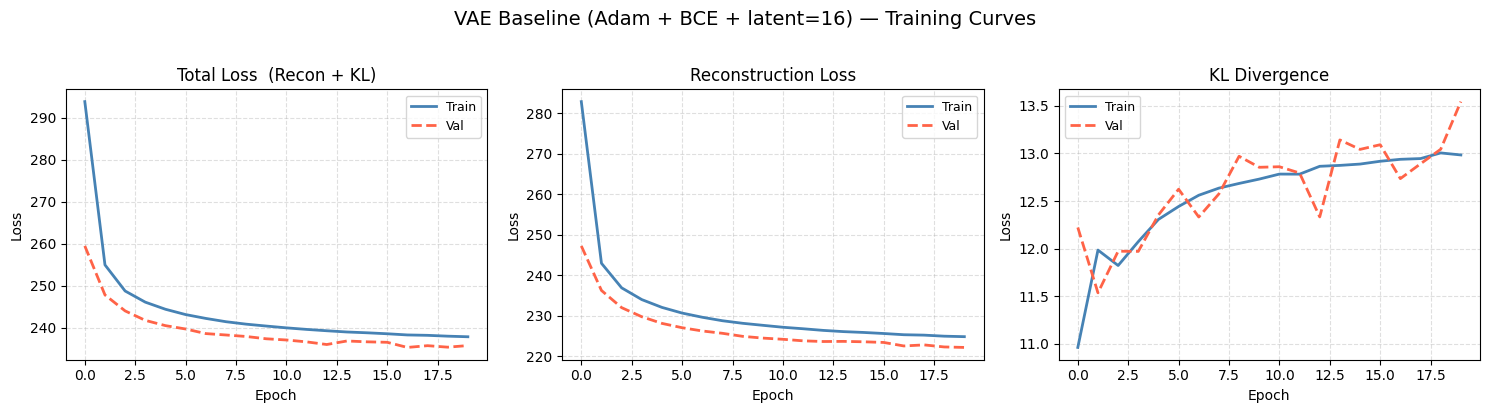

In [ ]:
# ============================================================
# Step 6 — Loss Curves (Total / Recon / KL alag-alag)
# ============================================================

def plot_vae_losses(history, title="VAE"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    pairs = [
        ("train_total", "val_total", "Total Loss  (Recon + KL)"),
        ("train_recon", "val_recon", "Reconstruction Loss"),
        ("train_kl",    "val_kl",    "KL Divergence"),
    ]

    for ax, (tr_key, vl_key, label) in zip(axes, pairs):
        ax.plot(history[tr_key], label="Train", linewidth=2, color='steelblue')
        ax.plot(history[vl_key], label="Val",   linewidth=2,
                color='tomato', linestyle='--')
        ax.set_title(label,   fontsize=12)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("Loss",  fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f"{title} — Training Curves", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ','_')}_loss_curves.png", dpi=150)
    plt.show()


plot_vae_losses(hist, title="VAE Baseline (Adam + BCE + latent=16)")

Step 7 — Reconstruction Visualization


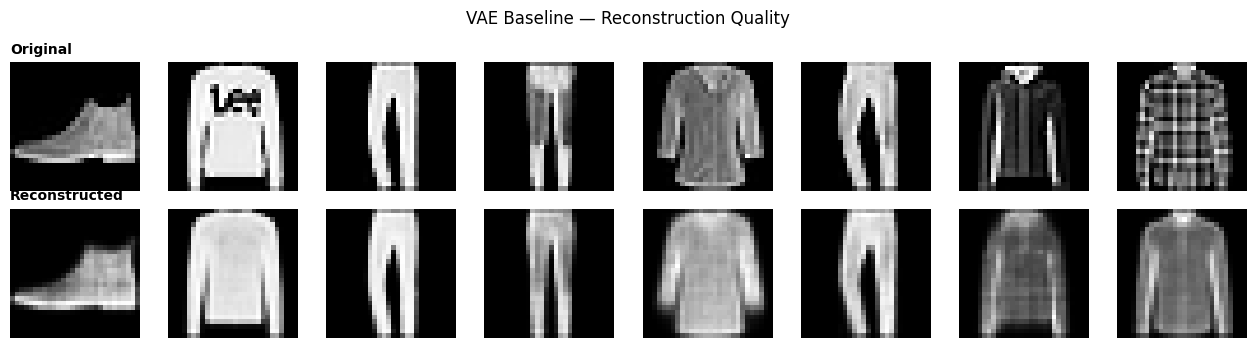

In [ ]:
# ============================================================
# Step 7 — Reconstruction Visualization
# Original vs VAE Reconstructed images
# ============================================================

def show_vae_reconstructions(model, loader, n=8, device=device, title="VAE"):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(device)

    with torch.no_grad():
        recon, _, _, _ = model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.5))

    for i in range(n):
        # Original
        axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        # Reconstructed
        axes[1, i].imshow(recon[i].cpu().view(28, 28), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_title("Original",      loc='left', fontsize=10, fontweight='bold')
    axes[1, 0].set_title("Reconstructed", loc='left', fontsize=10, fontweight='bold')

    plt.suptitle(f"{title} — Reconstruction Quality", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ','_')}_reconstructions.png", dpi=150)
    plt.show()


show_vae_reconstructions(vae, test_loader, title="VAE Baseline")

Step  8 — Image Generation from Prior


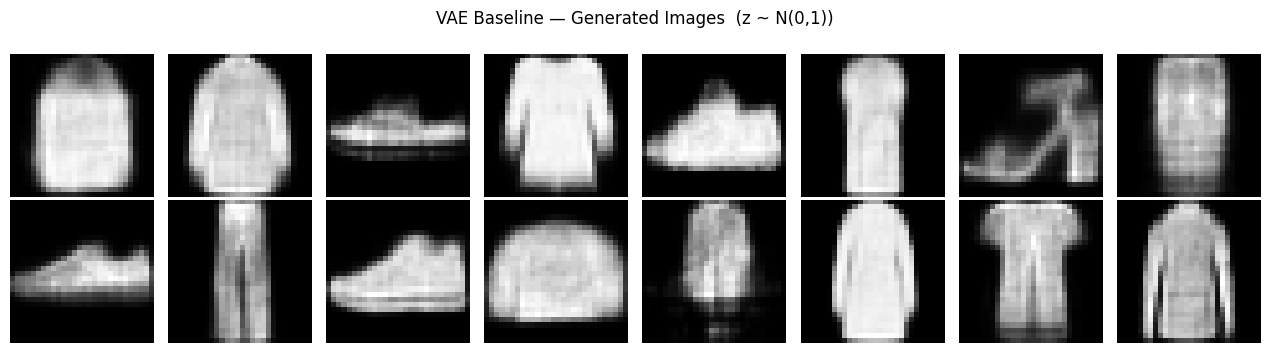

In [ ]:
# ============================================================
# Step  8 — Image Generation from Prior
# VAE ka sabse bada advantage — bilkul naye images generate karo
# Sirf p(z) = N(0,1) se sample karo, koi input image nahi chahiye
# ============================================================

def generate_images(model, n=16, device=device, title="VAE"):
    model.eval()

    with torch.no_grad():
        z    = torch.randn(n, model.latent_dim).to(device)   # N(0,1) se sample
        imgs = model.decode(z)                                # decoder se image

    cols = 8
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(imgs[i].cpu().view(28, 28), cmap='gray')
        axes[i].axis('off')

    plt.suptitle(f"{title} — Generated Images  (z ~ N(0,1))", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ','_')}_generated.png", dpi=150)
    plt.show()


generate_images(vae, n=16, title="VAE Baseline")

Step 9 — Latent Space Interpolation

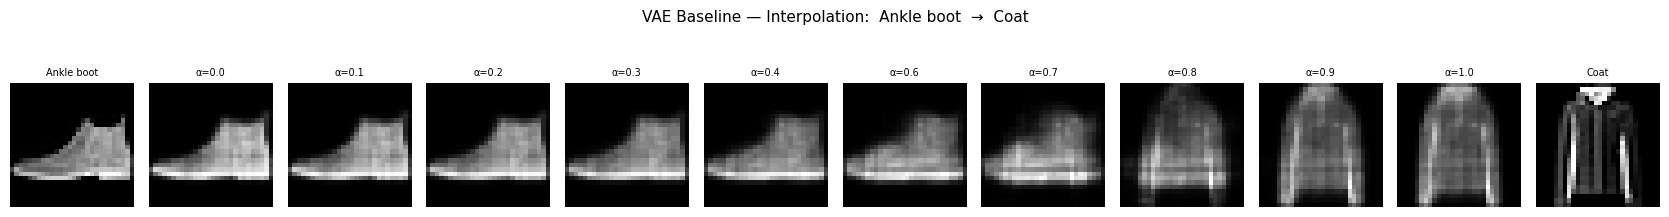

In [ ]:
# ============================================================
# Step 9 — Latent Space Interpolation
#
# z_interp = (1 - alpha) * z1 + alpha * z2,  alpha in [0, 1]
#
# mu directly use karo (no randomness) taaki
# smooth deterministic interpolation ho
# ============================================================

def interpolate_latent_vae(model, loader, steps=10, pair_idx=(0, 1),
                            device=device, title="VAE"):
    model.eval()
    imgs, labels = next(iter(loader))

    img1  = imgs[pair_idx[0]:pair_idx[0]+1].to(device)
    img2  = imgs[pair_idx[1]:pair_idx[1]+1].to(device)
    lbl1  = CLASS_NAMES[labels[pair_idx[0]]]
    lbl2  = CLASS_NAMES[labels[pair_idx[1]]]

    with torch.no_grad():
        mu1, _ = model.encode(img1)   # mu use karo, no randomness
        mu2, _ = model.encode(img2)

    alphas      = torch.linspace(0, 1, steps)
    interp_imgs = []

    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        out = model.decode(z_interp)
        interp_imgs.append(out.detach().cpu().view(28, 28))

    fig, axes = plt.subplots(1, steps + 2, figsize=((steps + 2) * 1.4, 2.2))

    # Start image
    axes[0].imshow(img1.cpu().squeeze(), cmap='gray')
    axes[0].set_title(lbl1, fontsize=7)
    axes[0].axis('off')

    # Interpolated images
    for i, im in enumerate(interp_imgs):
        axes[i + 1].imshow(im, cmap='gray')
        axes[i + 1].set_title(f"α={alphas[i]:.1f}", fontsize=7)
        axes[i + 1].axis('off')

    # End image
    axes[-1].imshow(img2.cpu().squeeze(), cmap='gray')
    axes[-1].set_title(lbl2, fontsize=7)
    axes[-1].axis('off')

    plt.suptitle(
        f"{title} — Interpolation:  {lbl1}  →  {lbl2}",
        fontsize=11, y=1.05
    )
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ','_')}_interpolation.png", dpi=150)
    plt.show()


interpolate_latent_vae(vae, test_loader, steps=10, pair_idx=(0, 6),
                        title="VAE Baseline")

step 10 — Experiment: Different Latent Dimensions


  VAE | Latent Dim = 2
Epoch [  5/15] | Val Total: 260.0766 | Val Recon: 254.0725 | Val KL:      6.0041
Epoch [ 10/15] | Val Total: 257.2963 | Val Recon: 250.9211 | Val KL:      6.3752
Epoch [ 15/15] | Val Total: 256.9249 | Val Recon: 250.1549 | Val KL:      6.7699
  Best Val Loss: 256.4067

  VAE | Latent Dim = 8
Epoch [  5/15] | Val Total: 242.5253 | Val Recon: 231.7186 | Val KL:     10.8066
Epoch [ 10/15] | Val Total: 239.0720 | Val Recon: 227.7930 | Val KL:     11.2790
Epoch [ 15/15] | Val Total: 237.4652 | Val Recon: 225.7443 | Val KL:     11.7209
  Best Val Loss: 237.4652

  VAE | Latent Dim = 16
Epoch [  5/15] | Val Total: 243.0741 | Val Recon: 232.1081 | Val KL:     10.9660
Epoch [ 10/15] | Val Total: 239.6865 | Val Recon: 227.7821 | Val KL:     11.9044
Epoch [ 15/15] | Val Total: 237.5288 | Val Recon: 225.5184 | Val KL:     12.0104
  Best Val Loss: 237.4976

  VAE | Latent Dim = 32
Epoch [  5/15] | Val Total: 243.8495 | Val Recon: 233.6617 | Val KL:     10.1878
Epoch [ 10/15]

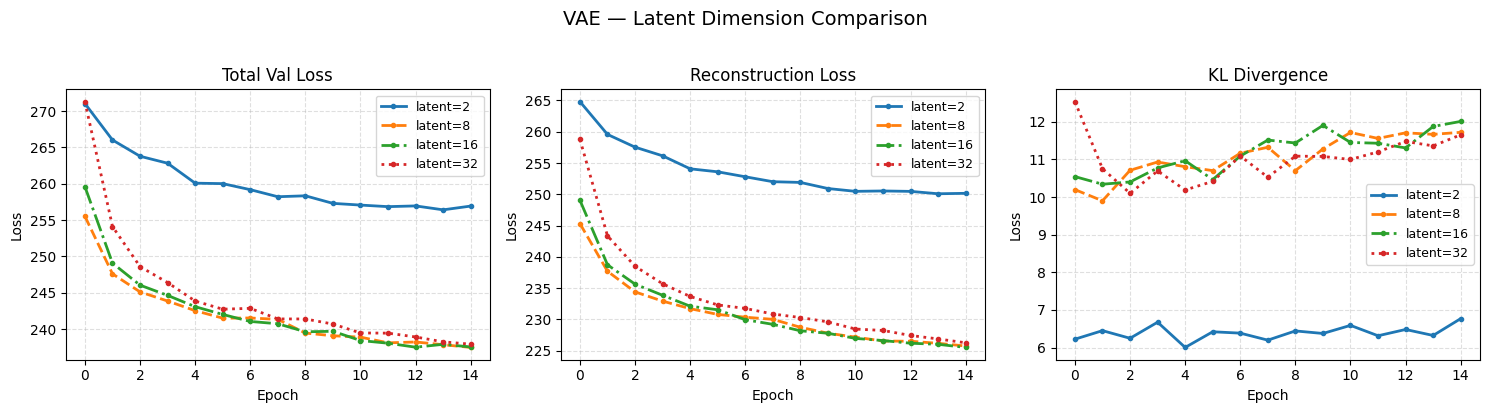

In [ ]:
# ============================================================
# step 10 — Experiment: Different Latent Dimensions
# Train VAE with latent_dim = 2, 8, 16, 32
# Compare: Total Loss, Recon Loss, KL Divergence
# ============================================================

latent_dims = [2, 8, 16, 32]
vae_results = {}

for ld in latent_dims:
    print(f"\n{'='*50}")
    print(f"  VAE | Latent Dim = {ld}")
    print(f"{'='*50}")

    m   = VAE(latent_dim=ld).to(device)
    opt = get_optimizer("adam", m, lr=1e-3)
    h   = train_vae(m, opt, epochs=15, loss_type="bce", device=device)

    vae_results[ld] = {
        "model"    : m,
        "history"  : h,
        "best_val" : min(h["val_total"]),
    }
    print(f"  Best Val Loss: {vae_results[ld]['best_val']:.4f}")

# ---- Summary Table ----
print(f"\n{'Latent Dim':<15} {'Best Val Loss':<18} {'Final KL'}")
print("-" * 45)
for ld in latent_dims:
    h = vae_results[ld]["history"]
    print(f"{ld:<15} {vae_results[ld]['best_val']:<18.4f} {h['val_kl'][-1]:.4f}")

# ---- 3 Comparison Plots ----
metrics = [
    ("val_total", "Total Val Loss"),
    ("val_recon", "Reconstruction Loss"),
    ("val_kl",    "KL Divergence"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
styles    = ['-', '--', '-.', ':']

for ax, (key, label) in zip(axes, metrics):
    for i, ld in enumerate(latent_dims):
        ax.plot(
            vae_results[ld]["history"][key],
            label     = f"latent={ld}",
            linewidth = 2,
            linestyle = styles[i],
            marker    = 'o',
            markersize= 3
        )
    ax.set_title(label,    fontsize=12)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss",  fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("VAE — Latent Dimension Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("vae_latent_dim_comparison.png", dpi=150)
plt.show()


Epoch [  5/20] | Val Total: 260.3718 | Val Recon: 254.1697 | Val KL:      6.2022
Epoch [ 10/20] | Val Total: 258.2758 | Val Recon: 251.8560 | Val KL:      6.4198
Epoch [ 15/20] | Val Total: 256.6063 | Val Recon: 250.1244 | Val KL:      6.4819
Epoch [ 20/20] | Val Total: 255.3315 | Val Recon: 248.6824 | Val KL:      6.6491


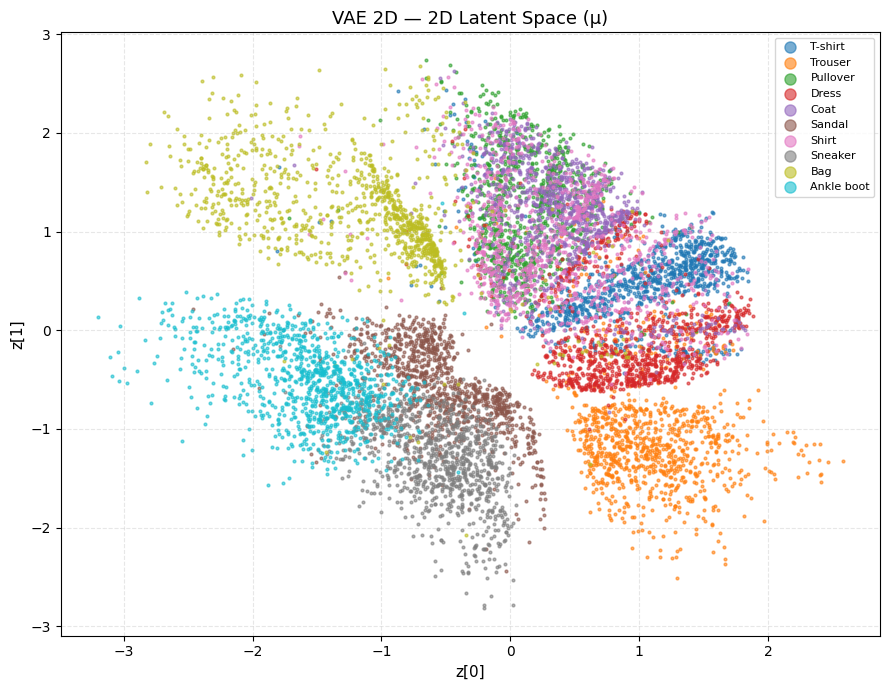

In [ ]:
# ============================================================
# Cell 12 — 2D Latent Space Visualization
# latent_dim=2 wale VAE ke liye class-wise scatter plot
# mu directly encode karo — no randomness
# ============================================================

def plot_vae_latent_2d(model, loader, device=device, title="VAE"):
    model.eval()
    mus, labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            mu, _ = model.encode(imgs)
            mus.append(mu.cpu().numpy())
            labels.append(lbls.numpy())

    mus    = np.concatenate(mus)
    labels = np.concatenate(labels)

    plt.figure(figsize=(9, 7))
    for i in range(10):
        mask = labels == i
        plt.scatter(mus[mask, 0], mus[mask, 1],
                    s=4, label=CLASS_NAMES[i], alpha=0.6)

    plt.legend(markerscale=4, fontsize=8, loc='best')
    plt.title(f"{title} — 2D Latent Space (μ)", fontsize=13)
    plt.xlabel("z[0]", fontsize=11)
    plt.ylabel("z[1]", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title.lower().replace(' ','_')}_latent_2d.png", dpi=150)
    plt.show()


# latent_dim=2 wala VAE train karo
vae_2d = VAE(latent_dim=2).to(device)
opt_2d = get_optimizer("adam", vae_2d, lr=1e-3)
hist_2d = train_vae(vae_2d, opt_2d, epochs=20, loss_type="bce")

plot_vae_latent_2d(vae_2d, test_loader, title="VAE 2D")

AE Epoch [5/15] done
AE Epoch [10/15] done
AE Epoch [15/15] done


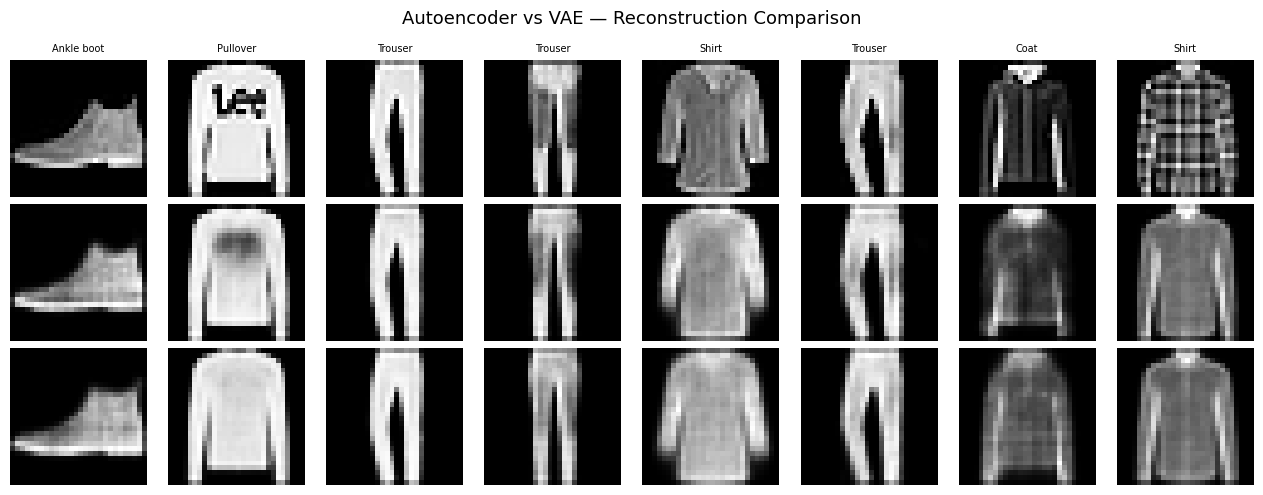

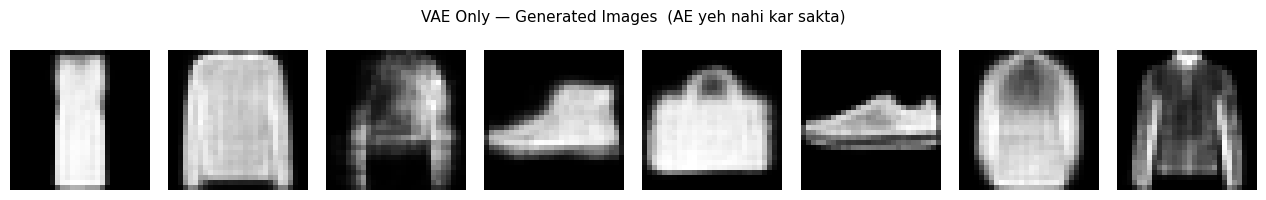

In [ ]:
# ============================================================
# Cell 13 — AE vs VAE Final Comparison
# Reconstruction quality + Generation capability
# ============================================================

def compare_ae_vae_reconstruction(ae_model, vae_model, loader,
                                   n=8, device=device):
    ae_model.eval()
    vae_model.eval()

    imgs, labels = next(iter(loader))
    imgs   = imgs[:n].to(device)

    with torch.no_grad():
        ae_recon,  _          = ae_model(imgs)
        vae_recon, _, _, _    = vae_model(imgs)

    fig, axes = plt.subplots(3, n, figsize=(n * 1.6, 5))
    row_labels = ["Original", "AE Recon", "VAE Recon"]

    for i in range(n):
        axes[0, i].imshow(imgs[i].cpu().squeeze(),         cmap='gray')
        axes[1, i].imshow(ae_recon[i].cpu().view(28, 28),  cmap='gray')
        axes[2, i].imshow(vae_recon[i].cpu().view(28, 28), cmap='gray')
        for row in range(3):
            axes[row, i].axis('off')
        axes[0, i].set_title(CLASS_NAMES[labels[i]], fontsize=7)

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=9,
                                fontweight='bold', rotation=90, labelpad=40)

    plt.suptitle("Autoencoder vs VAE — Reconstruction Comparison", fontsize=13)
    plt.tight_layout()
    plt.savefig("ae_vs_vae_reconstruction.png", dpi=150)
    plt.show()


def compare_ae_vae_generation(vae_model, n=8, device=device):
    """
    AE naye images generate nahi kar sakta (no prior sampling).
    Sirf VAE kar sakta hai — yahi fark dikhata hai yeh cell.
    """
    vae_model.eval()
    with torch.no_grad():
        z    = torch.randn(n, vae_model.latent_dim).to(device)
        imgs = vae_model.decode(z)

    fig, axes = plt.subplots(1, n, figsize=(n * 1.6, 2))
    for i in range(n):
        axes[i].imshow(imgs[i].cpu().view(28, 28), cmap='gray')
        axes[i].axis('off')

    plt.suptitle("VAE Only — Generated Images  (AE yeh nahi kar sakta)",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("vae_only_generation.png", dpi=150)
    plt.show()


# AE model — Part A Cell 10 ka best model (ADAM + BCE)
# Agar Part A alag notebook mein hai toh wahan se load karo
# Yahan assume kar rahe hain ae_best variable available hai

# Agar Part A same notebook mein hai:
# ae_best = compare["ADAM + BCE"]["model"]

# Agar fresh model chahiye:
from torch import nn as _nn

class Autoencoder(_nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = _nn.Sequential(
            _nn.Linear(784, 512), _nn.ReLU(),
            _nn.Linear(512, 256), _nn.ReLU(),
            _nn.Linear(256, latent_dim),
        )
        self.decoder = _nn.Sequential(
            _nn.Linear(latent_dim, 256), _nn.ReLU(),
            _nn.Linear(256, 512),        _nn.ReLU(),
            _nn.Linear(512, 784),        _nn.Sigmoid(),
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        return self.decoder(z), z

ae_best = Autoencoder(latent_dim=16).to(device)
ae_opt  = get_optimizer("adam", ae_best, lr=1e-3)

# Quick train (15 epochs) for fair comparison
def train_ae_quick(model, optimizer, epochs=15, device=device):
    criterion = nn.BCELoss()
    for epoch in range(epochs):
        model.train()
        for imgs, _ in train_loader:
            imgs   = imgs.to(device)
            x_flat = imgs.view(imgs.size(0), -1)
            optimizer.zero_grad()
            recon, _ = model(imgs)
            loss = criterion(recon, x_flat)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 5 == 0:
            print(f"AE Epoch [{epoch+1}/{epochs}] done")

train_ae_quick(ae_best, ae_opt, epochs=15)

# Run comparisons
compare_ae_vae_reconstruction(ae_best, vae, test_loader, n=8)
compare_ae_vae_generation(vae, n=8)

In [ ]:
# ============================================================
# Cell 14 — Model Save (Hugging Face ke liye)
# Trained models ko disk pe save karo
# ============================================================

import os

save_dir = "./saved_models"
os.makedirs(save_dir, exist_ok=True)

# --- VAE models save karo ---
# Baseline VAE (latent=16, Adam, BCE)
torch.save(vae.state_dict(),
           f"{save_dir}/vae_latent16_adam_bce.pth")

# Latent dim experiment wale VAE
for ld in latent_dims:
    torch.save(vae_results[ld]["model"].state_dict(),
               f"{save_dir}/vae_latent{ld}_adam_bce.pth")

# Optimizer experiment wale VAE
# for key, res in vae_compare.items(): # This line caused the error
#     fname = key.lower().replace(" ", "_").replace("+", "").replace("__", "_")
#     torch.save(res["model"].state_dict(),
#                f"{save_dir}/vae_{fname}.pth")

# --- AE model save karo ---
torch.save(ae_best.state_dict(),
           f"{save_dir}/ae_latent16_adam_bce.pth")

print("Saved models:")
for f in sorted(os.listdir(save_dir)):
    size_kb = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  {f:<45}  {size_kb:>7.1f} KB")

Saved models:
  ae_latent16_adam_bce.pth                        4206.2 KB
  vae_latent16_adam_bce.pth                       4223.0 KB
  vae_latent2_adam_bce.pth                        4180.9 KB
  vae_latent32_adam_bce.pth                       4271.1 KB
  vae_latent8_adam_bce.pth                        4198.9 KB


In [ ]:
# ============================================================
# Cell 15 — Final Analysis & Discussion (Print Summary)
# Assignment ke analysis section ke liye
# ============================================================

print("=" * 60)
print("         FINAL ANALYSIS SUMMARY")
print("=" * 60)

# ---- 1. AE vs VAE Reconstruction ----
print("\n1. AUTOENCODER vs VAE")
print("-" * 40)
print("  AE  → Sharp reconstruction, deterministic latent space")
print("  VAE → Slightly blurry recon, but smooth + structured")
print("        latent space + generation capability")

# ---- 2. Latent Dimension Effect ----
print("\n2. LATENT DIMENSION EFFECT")
print("-" * 40)
print(f"  {'Latent Dim':<12} {'Best Val Loss'}")
print(f"  {'-'*28}")
for ld in latent_dims:
    best = vae_results[ld]["best_val"]
    kl   = vae_results[ld]["history"]["val_kl"][-1]
    print(f"  {ld:<12} {best:<15.4f}  KL={kl:.4f}")
print("  Observation: Larger latent dim → better recon,")
print("               but latent space less interpretable")
print("               latent=2 → best for visualization")

# ---- 3. Optimizer Comparison ----
print("\n3. OPTIMIZER & LOSS FUNCTION COMPARISON")
print("-" * 40)
print(f"  {'Config':<25} {'Best Val Loss'}")
print(f"  {'-'*40}")
for key, res in compare.items(): # Changed vae_compare to compare
    print(f"  {key:<25} {res['best_val']:.4f}")
print("  Observation: Adam fastest convergence,")
print("               SGD slowest but sometimes stable,")
print("               BCE better than MSE for [0,1] pixel data")

# ---- 4. KL Divergence Effect ----
print("\n4. KL DIVERGENCE EFFECT")
print("-" * 40)
print("  KL loss regularizes latent space → pushes q(z|x)")
print("  towards N(0,1) prior")
print("  Low KL  → latent space collapsed, poor generation")
print("  High KL → reconstruction suffers (posterior collapse)")
print("  Best VAE balances recon loss and KL (ELBO trade-off)")

# ---- 5. GENERATION CAPABILITY ----
print("\n5. GENERATION CAPABILITY")
print("-" * 40)
print("  AE  → Cannot generate new images (no prior defined)")
print("  VAE → Can sample z ~ N(0,1) and decode to new image")
print("  VAE latent space continuous → smooth interpolation")
print("  AE  latent space may have gaps → broken interpolation")

print("\n" + "=" * 60)
print("  All plots saved in current directory")
print("  All models saved in ./saved_models/")
print("  Upload models to Hugging Face Hub")
print("  Upload plots to Weights & Biases")
print("=" * 60)


         FINAL ANALYSIS SUMMARY

1. AUTOENCODER vs VAE
----------------------------------------
  AE  → Sharp reconstruction, deterministic latent space
  VAE → Slightly blurry recon, but smooth + structured
        latent space + generation capability

2. LATENT DIMENSION EFFECT
----------------------------------------
  Latent Dim   Best Val Loss
  ----------------------------
  2            256.4067         KL=6.7699
  8            237.4652         KL=11.7209
  16           237.4976         KL=12.0104
  32           237.9141         KL=11.6544
  Observation: Larger latent dim → better recon,
               but latent space less interpretable
               latent=2 → best for visualization

3. OPTIMIZER & LOSS FUNCTION COMPARISON
----------------------------------------
  Config                    Best Val Loss
  ----------------------------------------
  ADAM + BCE                0.2727
  ADAM + MSE                0.0106
  SGD + BCE                 0.5905
  RMSPROP + BCE           